# **LOGISTIC REGRESSION - CLASSIFIER**

---

<br>

### What is Logistic Regression?
- **Purpose**: Used for predicting **binary outcomes** (0 or 1, yes or no).
- **Output**: Gives a probability between 0 and 1 that an instance belongs to class 1.

<br>

---

<br>


### Key Concepts:
1. **Sigmoid Function**:
   - Transforms any number into a value between 0 and 1.
   - Formula:

     $ \sigma(z) = \frac{1}{1 + e^{-z}} $

   - If the result is **greater than 0.5**, predict class **1** (yes).
   - If **less than or equal to 0.5**, predict class **0** (no).

<br> 

2. **Training the Model**:
   - **Learn weights** from the data to make the best predictions.
   - Uses **log loss** to measure errors during training.

<br>

3. **Decision Boundary**:
   - The threshold (usually 0.5) is used to decide between the two classes.

<br>
   
4. **Formula**:
   - The logistic model calculates:

     $ P(y = 1 | X) = \sigma(w^T X + b) $

   - Where:
     - \( w \) = weights
     - \( X \) = input features
     - \( b \) = bias

<br>

---

<br>

### Evaluation:
- **Accuracy**: How many predictions are correct.
- **Confusion Matrix**: Shows true/false positives and negatives.
- **Precision & Recall**: Performance metrics for imbalanced data.

<br>

---

<br>

### Overview:
Logistic regression is a simple model for binary classification. It uses the sigmoid function to predict probabilities and makes decisions based on a threshold (usually 0.5). It learns from data and adjusts weights to improve predictions.

<br>

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

In [2]:
df = pd.read_csv('/content/11_titanic_data.csv')

## **EDA & FEATURE ENGINEERING**

In [3]:
# Q1) what is the overall survival rate
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [4]:
# We can get in percentage by using normalize = True
df['Survived'].value_counts(normalize = True)

,proportion
Survived,
0,0.616162
1,0.383838


<Axes: xlabel='Sex', ylabel='count'>

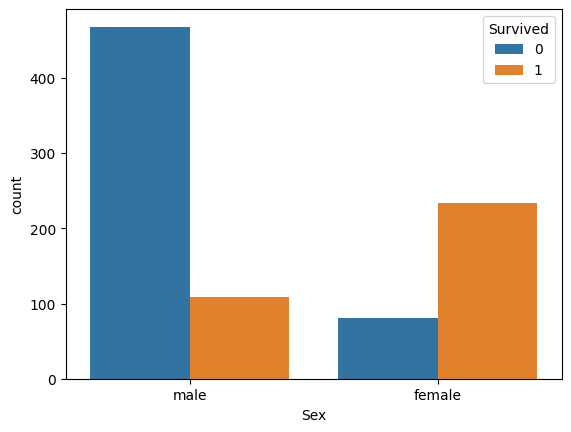

In [5]:
# Q2) Survival rate based on gender
sns.countplot(data = df, x = 'Sex', hue = 'Survived')

<Axes: xlabel='Pclass', ylabel='count'>

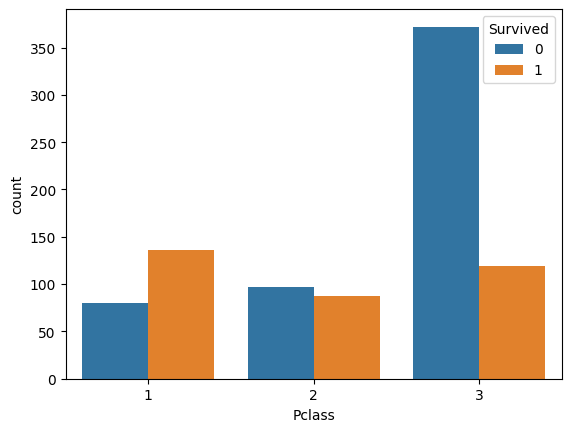

In [6]:
# Q3) Survival rate across different classes (P class)
sns.countplot(data = df, x = 'Pclass', hue = 'Survived')

In [7]:
df1 = df

In [8]:
df2 = df1.dropna(subset=['Age'])

<Axes: xlabel='Age', ylabel='Count'>

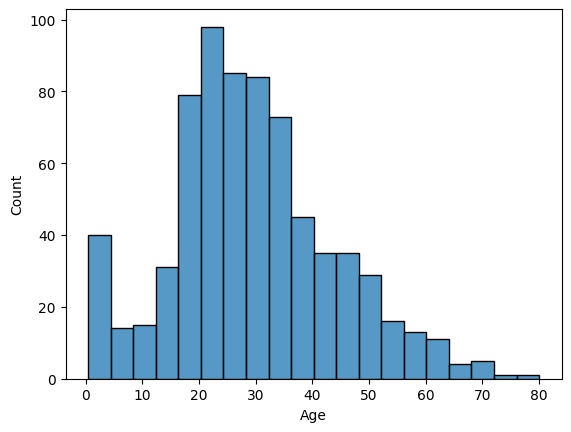

In [9]:
# Q4) what is the age distribution of passengers
sns.histplot(df2['Age'])

<Axes: xlabel='Fare', ylabel='count'>

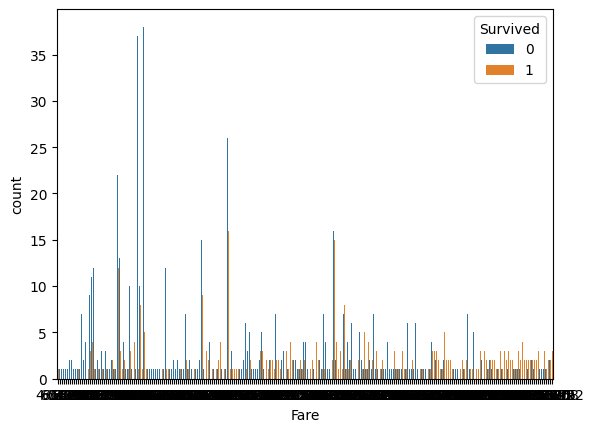

In [10]:
# Q5) does price has a correlation with survival rate
sns.countplot(data = df, x = 'Fare', hue = 'Survived')

In [11]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [12]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [13]:
df.drop('Cabin', axis = 1, inplace = True)

In [14]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [15]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [16]:
df = df.dropna(subset=['Embarked'])

In [17]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


<Axes: xlabel='Age', ylabel='Count'>

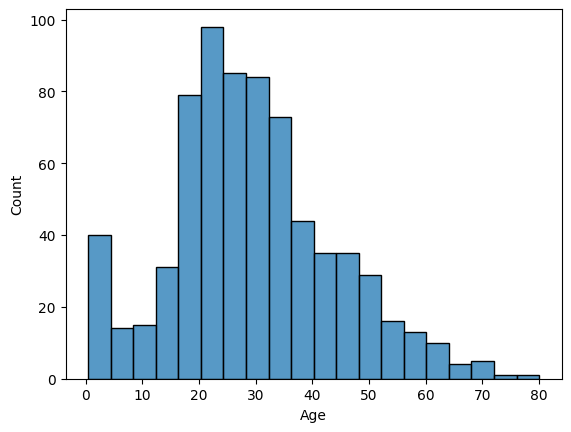

In [18]:
sns.histplot(df['Age'])

In [19]:
data = pd.get_dummies(df,columns = ['Sex'], drop_first=True, dtype = 'int')

In [20]:
X = data.drop(['Name', 'Age', 'PassengerId', 'Survived', 'Ticket', 'Fare', 'Embarked'], axis = 1)
Y = data['Survived']

In [21]:
X

,Pclass,SibSp,Parch,Sex_male
0,3,1,0,1
1,1,1,0,0
2,3,0,0,0
3,1,1,0,0
4,3,0,0,1
...,...,...,...,...
886,2,0,0,1
887,1,0,0,0
888,3,1,2,0
889,1,0,0,1


In [22]:
X_train,X_test,Y_train, Y_test = train_test_split(X,Y, test_size = 0.2)

In [23]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## **LOGISTIC REGRESSION MODEL**

In [24]:
model = LogisticRegression()
model.fit(X_train, Y_train)

LogisticRegression()

In [25]:
Y_pred = model.predict(X_test)

In [26]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.88      0.90      0.89       117
           1       0.79      0.75      0.77        61

    accuracy                           0.85       178
   macro avg       0.83      0.83      0.83       178
weighted avg       0.85      0.85      0.85       178

